In [1]:
# from TransferModels import TransferModel, TransferModelDownsample
from rioss_prep_training.rioss_models import TransferModels as tm
from pytorch_lightning import Trainer
import torch
from torch import tensor
from monai.inferers import sliding_window_inference
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import json
from pathlib import Path
from matplotlib.colors import ListedColormap, BoundaryNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from torchmetrics.classification import BinaryF1Score, BinaryRecall, BinaryPrecision, F1Score
from monai.transforms import Resize

In [2]:
def inference(model, image, batch_size=24, overlap=0.8, roi_size=None):
    model.freeze()

    if roi_size == None:
        roi_size = model.input_size
    
    image = image.reshape(1, -1, image.shape[-2], image.shape[-1])
    image = image.to(model.device)
    preds_output = sliding_window_inference(image, 
                roi_size=roi_size,
                sw_batch_size=batch_size, 
                predictor=model, 
                mode='gaussian',
                overlap=overlap,
                progress=True
                )

    return preds_output.to('cpu').reshape(*preds_output.shape[-2:])


def imshow_inference(model, original_img, inference_img, color_steps=7, save_path=None):
        fig, axs = plt.subplots(ncols=2)
        for ax in axs.flatten():
            ax.axis('off')

        levels = np.linspace(0, 1, color_steps) 
        colors = plt.cm.turbo(np.linspace(0, 1, len(levels)-1))
        cmap = ListedColormap(colors)
        norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

        axs[0].imshow(original_img)
        axs[0].set_title("ORIGINAL", fontsize=20)

        cax = axs[1].imshow(inference_img, cmap=cmap, norm=norm)
        axs[1].set_title(F"{model.__class__.__name__}", fontsize=20)

        divider = make_axes_locatable(axs[1])
        cax_cb = divider.append_axes("right", size="5%", pad=0.05)
        cbar = fig.colorbar(cax, cax=cax_cb, ticks=levels, boundaries=levels)
        cbar.ax.set_yticklabels(['{:.2f}'.format(level) for level in levels])
        
        fig.set_size_inches(15, 5)
        plt.show()
        
        if not save_path == None:
            fig.savefig(save_path, dpi=400)
            # fig.savefig(weights.parent / 'inferences' / nc_image_path.stem, dpi=400)

def nc_path_toimage(nc_path, name):
    original_img = xr.open_dataset(nc_path)[name]
    original_img = torch.nan_to_num(tensor(original_img.values))
    return original_img

def run_model_test(model, nc_name, nc_img_folder, weights):
    nc_image_path = (nc_img_folder / nc_name).with_suffix('.nc')
    original_img = nc_path_toimage(nc_image_path)
    inference_img = inference(model, original_img, batch_size=24, overlap=0.8, roi_size=model.dataset_img_size)
    save_name = weights.parent / 'inferences' / nc_image_path.stem
    imshow_inference(model, original_img, inference_img, save_name=save_name)

def get_f1_score(inference, label):
     inference = inference.reshape(1, -1, *inference.shape)
     label = label.reshape(1, -1, *label.shape[2:])
     return BinaryF1Score()(torch.tensor(inference), torch.tensor(label))
     

     

In [15]:
weights = '/mnt/camobi_2/PHMG/experiments/TransferModelDownsample_resnet34_input=512_lr=1.00e-04/model_logs/version_7/model-val_loss=0.019796-val_f1_score=0.733-val_precision=0.871-val_recall=0.667.ckpt'
weights = '/mnt/camobi_2/PHMG/swin_unetr_models/test/model_logs/version_484/model-Val_loss=0.018319-Val_Precision=0.712-Recall=0.890-Val_F1_Score=0.787.ckpt'
weights = '/mnt/camobi_2/PHMG/experiments/TransferModelDownsample_resnet34_input=512_lr=1.00e-04/model_logs/version_9/model-val_loss=0.016146-val_f1_score=0.739-val_precision=0.838-val_recall=0.673.ckpt'
# weights = '/mnt/camobi_2/PHMG/experiments/TransferModelDownsample_resnext50_32x4d_input=512_lr=1.00e-04/model_logs/version_2/model-val_loss=0.015224-val_f1_score=0.729-val_precision=0.789-val_recall=0.731.ckpt'
weights = '/mnt/camobi_2/PHMG/experiments/TransferModelDownsample_resnet101_input=512_lr=1.00e-04/model_logs/version_2/model-val_loss=0.017632-val_f1_score=0.748-val_precision=0.908-val_recall=0.648.ckpt'
weights = '/mnt/camobi_2/PHMG/experiments/TransferModelDownsample_resnet34_input=512_lr=1.00e-04/model_logs/version_17/model-val_loss=0.007045-val_f1_score=0.880-val_precision=0.882-val_recall=0.885.ckpt'
weights = '/mnt/camobi_2/PHMG/experiments/TransferModelDownsample_resnet34_input=512_lr=1.00e-04/model_logs/version_3/model-val_loss=0.004677-val_f1_score=0.908-val_precision=0.895-val_recall=0.925.ckpt'
weights = '/mnt/camobi_2/PHMG/experiments/TransferModelDownsample_vgg19_bn_input=512_lr=1.00e-04/model_logs/version_10/model-val_loss=0.004367-val_f1_score=0.886-val_precision=0.903-val_recall=0.882.ckpt'
# weights = '/mnt/camobi_2/PHMG/experiments/TransferModelDownsample_resnet34_input=512_lr=1.00e-04/model_logs/version_3/model-val_loss=0.003385-val_f1_score=0.897-val_precision=0.950-val_recall=0.852.ckpt'
# weights = '/mnt/camobi_2/PHMG/exp eriments_delete/TransferModelDownsample_resnet50_input=512_lr=1.00e-04/model-val_loss=0.008087-val_f1_score=0.800-val_precision=0.842-val_recall=0.787.ckpt'
weights = '/mnt/camobi_2/PHMG/experiments_delete/SMP_resnet50_input=512_lr=1.00e-04/model_logs/version_0/model-val_loss=0.005649-val_f1_score=0.867-val_precision=0.861-val_recall=0.876.ckpt'
# weights = '/mnt/camobi_2/PHMG/experiments_delete/SMP_resnet50_input=512_lr=1.00e-04/model_logs/version_3/model-val_loss=0.002925-val_f1_score=0.840-val_precision=0.844-val_recall=0.842.ckpt'
# weights = '/mnt/camobi_2/PHMG/delete_callback_test/model-val_loss=0.003800-val_f1_score=0.871-val_precision=0.875-val_recall=0.868.ckpt'
weights = '/mnt/camobi_2/PHMG/delete_callback_test/model-val_loss=0.005293-val_f1_score=0.845-val_precision=0.932-val_recall=0.776.ckpt'
weights = '/mnt/camobi_2/PHMG/delete_callback_test/model-val_loss=0.003684-val_f1_score=0.859-val_precision=0.863-val_recall=0.858.ckpt'
weights = Path(weights)
model = tm.SMP.load_from_checkpoint(weights, in_channels=1, input_size=512, activation='sigmoid', map_location='cuda:1')
# model = tm.TransferSegformer.load_from_checkpoint(weights, input_size=512, map_location='cuda:1')

RuntimeError: Error(s) in loading state_dict for SMP:
	size mismatch for model.encoder.conv1.weight: copying a param with shape torch.Size([64, 2, 7, 7]) from checkpoint, the shape in current model is torch.Size([64, 1, 7, 7]).

In [4]:
# large_patch_weights = '/mnt/camobi_2/PHMG/swin_unetr_models/test/model_logs/version_340/model-Val_loss=0.001278-Val_Precision=0.948-Recall=0.931-Val_F1_Score=0.939.pt'
# model = TransferModelDownsample(input_size=512, dataset_img_size=2048, in_channels=1, lr=8e-5, encoder_name="resnet50", activation='sigmoid')
# model.to('cuda:0')
# model.load_state_dict(torch.load(large_patch_weights), strict=False)



In [14]:
JSON_SPLIT_PATH = Path('/mnt/camobi_3/new_data/train_val.json')
NC_IMG_FOLDER = Path('/mnt/camobi_process/test_dataset')
NC_IMG_FOLDER = Path('/mnt/camobi_3/new_data/nc_data')
with open(JSON_SPLIT_PATH, 'r') as json_file:
    train_val_dict = json.load(json_file)

two_channels = False
nc_image_path = (NC_IMG_FOLDER / 'CCBB').with_suffix('.nc')
original_img = nc_path_toimage(nc_image_path, 'Sigma0_VV_db')
if two_channels:
    wind_speed = nc_path_toimage(nc_image_path, 'wind_speed')
    original_img = torch.stack((original_img, wind_speed), axis=0)

upsample_fn = torch.nn.Upsample(scale_factor=512 / (2048 * 1) , mode='nearest')
original_img = upsample_fn(original_img.reshape(1, -1, original_img.shape[-2], original_img.shape[-1]))
original_img = original_img.squeeze().type(torch.float)

inference_img = inference(model, original_img, batch_size=4, overlap=0.5, roi_size=512)



plt.figure(figsize=(10, 10))
imshow_inference(model, original_img, inference_img)

KeyError: "No variable named 'wind_speed'. Variables on the dataset include ['Sigma0_VV_db', 'latitude', 'longitude', 'slant_range_time', 'incident_angle', 'lat', 'lon']"

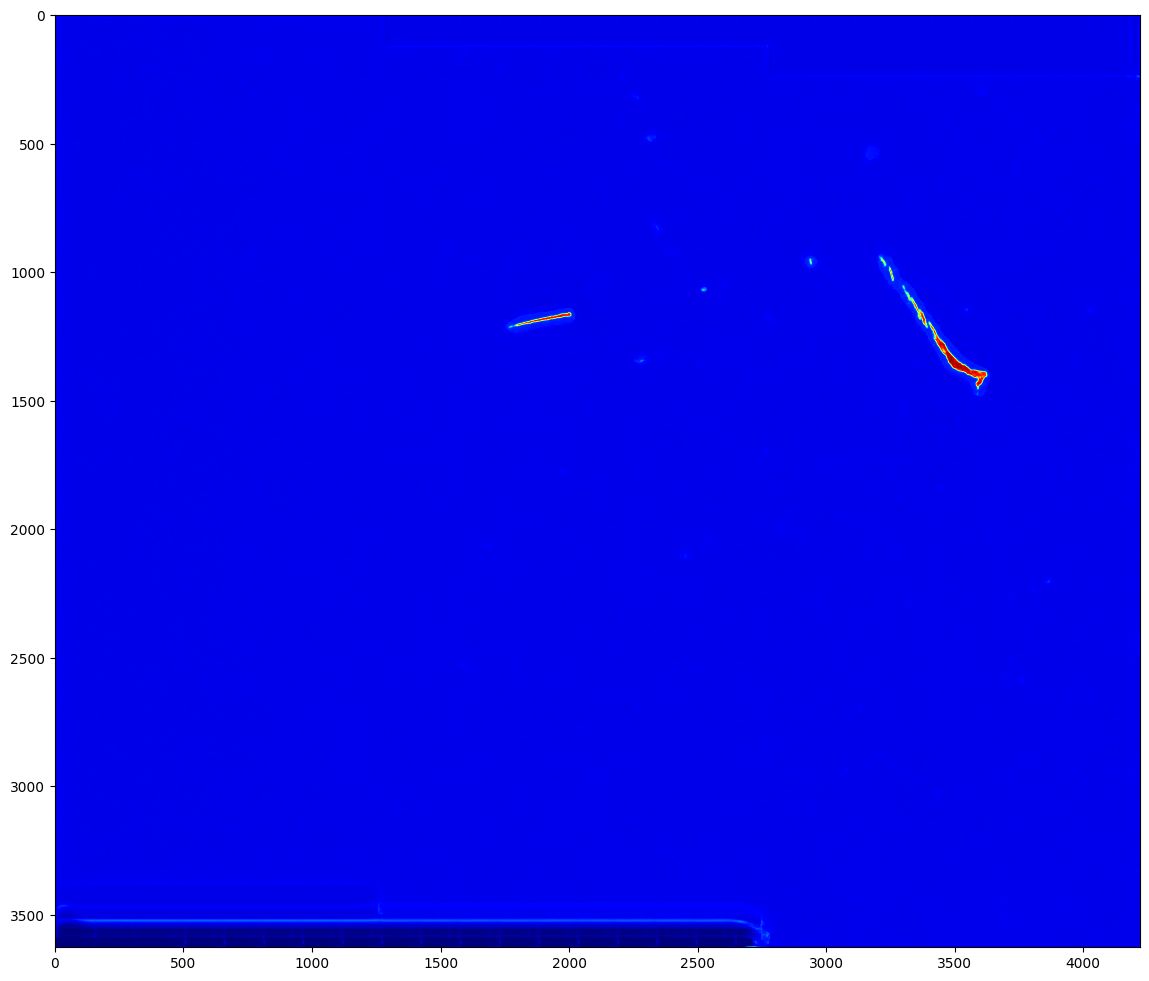

In [10]:
plt.figure(figsize=(14, 14))
plt.imshow(inference_img, cmap='jet')

In [33]:
inference_img[1000][1000]

tensor(0.0888)

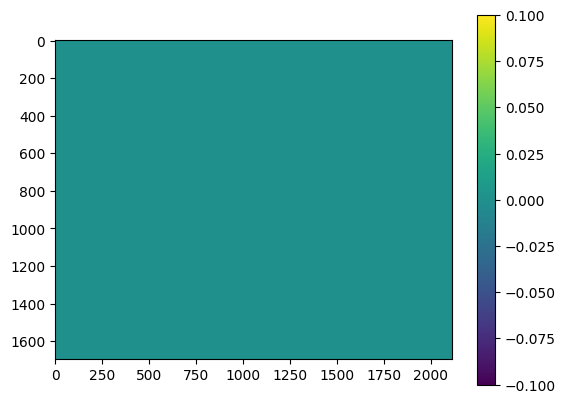

In [28]:
plt.imshow(original_img[1])
plt.colorbar()

In [9]:
label = nc_path_toimage(nc_image_path, 'label')
label = torch.where(label==1, 1, 0).type(torch.float)
label = upsample_fn(label.reshape(1, -1, *label.shape))
get_f1_score(inference_img, label)

/tmp/ipykernel_985072/713557124.py:64: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return BinaryF1Score()(torch.tensor(inference), torch.tensor(label))


tensor(0.8715)

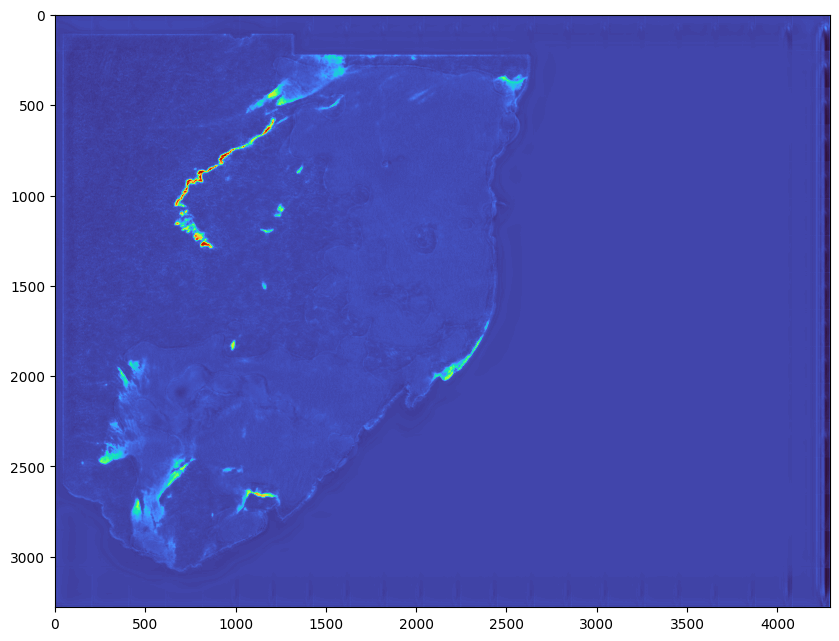

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(inference_img, cmap='turbo')

In [ ]:
weights = '/mnt/camobi_2/PHMG/experiments/TransferModelDownsample_resnet34_input=512_lr=1.00e-04/model_logs/version_3/model-val_loss=0.003385-val_f1_score=0.897-val_precision=0.950-val_recall=0.852.ckpt'
weights = Path(weights)
model = TransferModelDownsample.load_from_checkpoint(weights, input_size=512, dataset_img_size=2048, activation='sigmoid')

inference_img_2 = inference(model, original_img, batch_size=24, overlap=0.8, roi_size=model.dataset_img_size)

NameError: name 'TransferModelDownsample' is not defined

In [ ]:
inference_img_3 = (inference_img + inference_img_2) / 2
json_path = (NC_IMG_FOLDER.parent / 'labels_json' / nc_image_path.stem).with_suffix('.json')
from Sentinel_Process import NetcdfProduct
import netCDF4 as nc

dict_label = {1: ['oil'], 
           2: ['land'], 
           3: ['dark-ocean'], 
           4: ['dark-land'], 
           5: ['low-wind'], 
           6: ['ship'],
           0: ['ocean']}

mask = NetcdfProduct(nc.Dataset(nc_image_path))
mask = mask.polygons_to_img(json_path, dict_label)
mask = torch.from_numpy(np.where(mask == 1, 1, 0)).type(torch.int16)

mask = mask.reshape(1, -1, *mask.shape[-2:]) .type(torch.uint8)   
device = 'cuda:0'
mask = model.upsample_fn(mask)
mask = mask.to(device)

for inference_img_ in [inference_img, inference_img_2, inference_img_3]:
    test_inference_img = inference_img_.reshape(1, -1, *inference_img.shape[-2:])
    test_inference_img = test_inference_img.to(device)

    print(BinaryF1Score().to(device)(test_inference_img, mask), 
          BinaryPrecision().to(device)(test_inference_img, mask),
          BinaryRecall().to(device)(test_inference_img, mask))




In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(inference_img_2, cmap='turbo')
# plt.savefig('test', dpi=600)

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(mask[0][0].cpu(), cmap='turbo')

test_inference_img[mask.bool()] = np.nan  

In [ ]:

fds
for original_img in train_val_dict['val']:
    nc_image_path = (NC_IMG_FOLDER / original_img).with_suffix('.nc')
    original_img = xr.open_dataset(nc_image_path).Sigma0_VV_db
    original_img = torch.nan_to_num(tensor(original_img.values))
    inference_img = inference(model, original_img, batch_size=24, overlap=0.8, roi_size=model.dataset_img_size)
    save_name = weights.parent / 'inferences' / nc_image_path.stem
    imshow_inference(model, original_img, inference_img, save_name=save_name)
    break


In [ ]:
weights.parent / 'inferences' / nc_image_path.stem

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(test.squeeze(), cmap='jet')  

In [ ]:
threshold = 0.5
mask_model = test.squeeze().clone()
mask_model[mask_model > threshold] = 1
mask_model[mask_model < threshold] = 0

plt.figure(figsize=(10, 10))
plt.imshow(mask_model, cmap='jet')

In [ ]:
test[0][0][0][0]

In [ ]:
from torchvision.transforms import Compose
from monai.transforms import RandRotate90d, RandAxisFlipd, SignalFillEmptyd, ToTensord, LoadImaged

class ToBinaryTransformd:
    def __init__(self, keys, label_num=1):
        self.keys = keys
        self.label_num = label_num

    def __call__(self, sample):
        for key in self.keys:
            sample[key] = torch.where(
                sample[key] == self.label_num, 
                torch.tensor(1, dtype=sample[key].dtype), 
                torch.tensor(0, dtype=sample[key].dtype)
            )
        return sample

output = {
    'img': '/mnt/camobi_process/dataset_test/label/border/0E78_1104.npy',
    'label': '/mnt/camobi_process/dataset_test/img/border/0E78_1104.npy'
}

transforms = Compose([
    LoadImaged(keys=["img", "label"]),
    ToTensord(keys=["img"], dtype=torch.float),
    ToTensord(keys=["label"], dtype=torch.uint8),
    ToBinaryTransformd(keys=["label"], label_num=1),
    SignalFillEmptyd(keys=["img", "label"], replacement=0.0),
    RandAxisFlipd(keys=["img", "label"], prob=2/3),
    RandRotate90d(keys=["img", "label"], prob=3/4)
])

In [ ]:
test = transforms(output)['label']
test

In [ ]:
upsample_fn = torch.nn.Upsample(scale_factor=512/2048, mode='nearest')
y = upsample_fn(test)

In [ ]:
import torch
import torch.nn.functional as F

# Example tensor with uint8 data type
x_uint8 = torch.tensor([[[1, 2],
                         [3, 4]]], dtype=torch.uint8)

# Upsample the tensor
upsampled_uint8 = F.interpolate(x_uint8.float().unsqueeze(0), scale_factor=2, mode='nearest').to(torch.uint8)

print(upsampled_uint8)



In [ ]:
input_data.dtype

In [ ]:
from TransferModels import TransferModelDownsample
from pathlib import Path
from datetime import datetime
import os





In [ ]:
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint, TQDMProgressBar, BatchSizeFinder, RichProgressBar
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning import Trainer
from sklearn.model_selection import train_test_split

from TransferModels import TransferModelDownsample, AutoencoderDownsampleModel
from UnetrModels import RiossMetaUnet, PedroNet
from torch import set_float32_matmul_precision
import time
from tqdm import tqdm

set_float32_matmul_precision('medium')


# model = TransferModelDownsample(
#     input_size=512, 
#     dataset_img_size=2048, 
#     in_channels=1, 
#     lr=1e-4, 
#     encoder_name="vgg19_bn",
#     activation=None,

# )

device = 'cuda:0'
weights = '/mnt/camobi_2/PHMG/swin_unetr_models/Model_512Img_24Feature_(2, 2, 2, 2)depths_0.0attnDrop_(3, 6, 12, 24)Heads_30.000000Lr_0drop_v1/model-Val_loss=0.003714-Val_Precision=0.973-Recall=0.971-Val_F1_Score=0.972.ckpt'
unet_model = PedroNet.load_from_checkpoint(weights, strict=False, map_location=device)
unet_model.freeze()

model = RiossMetaUnet(512, lr=1.5e-4, patch_model=unet_model, feature_size=12).to(device)

In [ ]:
import torch

test = model(torch.rand(1, 1, 2048, 2048).to(device))
test

In [ ]:
test.shape

In [13]:
xr.open_dataset('/mnt/camobi_process/new_dataset/040D.nc')['incident_angle']

<xarray.DataArray 'incident_angle' (y: 13172, x: 17191)>
[226439852 values with dtype=float32]
Coordinates:
    lat      (y, x) float64 ...
    lon      (y, x) float64 ...
Dimensions without coordinates: y, x